## Customer Churn Prediction


### Project Overview
This project predicts customer churn, also known as 'customer attrition'(whether a customer will stop doing business) using machine learning models, and identifies key factors that drive churn. The goal is to provide actionable insights for retention strategies.

### Problem Statement
Customer churn is a major business challenge in telecom, SaaS, and subscription-based industries. Predicting churn allows companies to:
- Identify at-risk customers
- Reduce revenue loss
- Design targeted retention campaigns

### Data
Teleco Customer Churn dataset from [Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

**The data set includes information about:**
- Customers who left within the last month – the column is called Churn
- Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
- Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
- Demographic info about customers – gender, age range, and if they have partners and dependents

### Project Workflow
1. Data Collection & Cleaning  
2. Exploratory Data Analysis (EDA)  
3. Feature Engineering  
4. Model Building (Pipeline containing Logistic Regression, Random Forest, XGBoost, Decision Tree and LightGBM)
5. Best model selection  
6. Model Evaluation (Accuracy, Recall, F1, ROC-AUC)  
7. Interpretability (Feature Importance, SHAP Values)  )  

## Results
- Best model: LightGBM with ROC-AUC: 75.3%
- Key churn drivers: **Contract length, Tenure, Monthly Charges, Online Security, and Paperless Billing** 

In [1]:
import pandas as pd
import numpy as np

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv('churn_data.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# Check target variable
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [7]:
# check for missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Data Cleaning

In [8]:
# convert monthly chalges and total charges to numeric data

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')

#filling missing values with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df['MonthlyCharges'].fillna(df['MonthlyCharges'].median(), inplace=True)

# Drop duplicates
df = df.drop_duplicates()

In [9]:
# Standardize the target variable
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [10]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Exploratory Data Analysis

<Axes: xlabel='Churn', ylabel='count'>

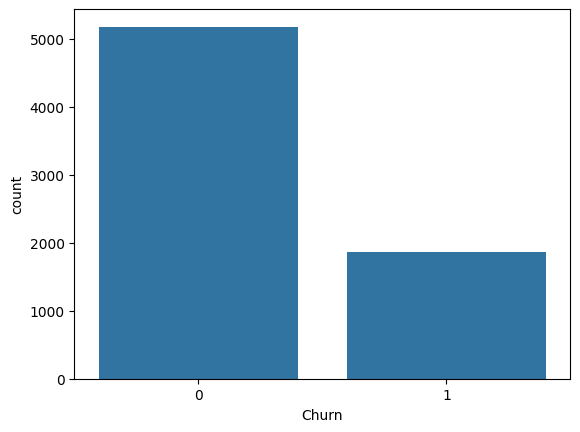

In [12]:
# Distribution of target variable
sns.countplot(x='Churn', data=df)

<Axes: xlabel='Contract', ylabel='count'>

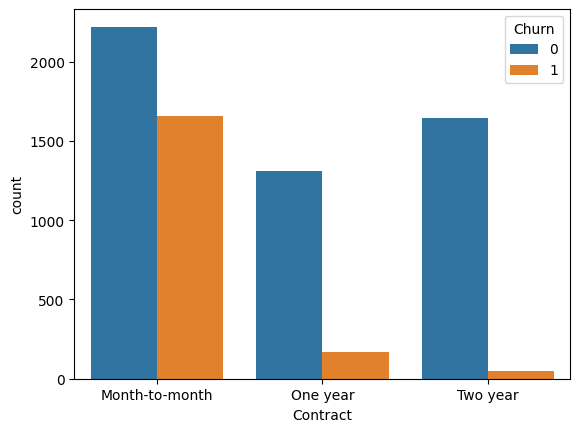

In [13]:
# Churn by contract type
sns.countplot(x='Contract', hue='Churn', data=df)

<Axes: xlabel='Churn', ylabel='tenure'>

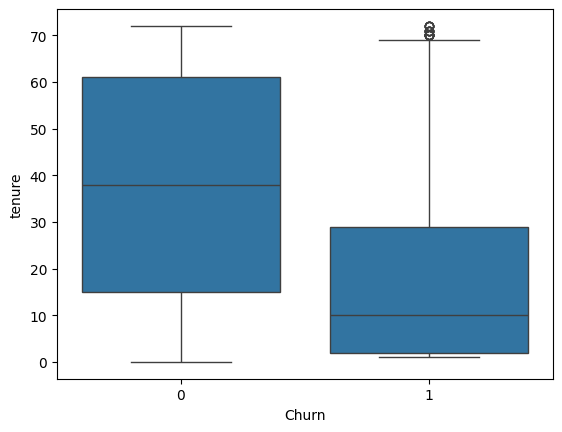

In [14]:
# Churn vs Tenure
sns.boxplot(x='Churn', y='tenure', data=df)

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

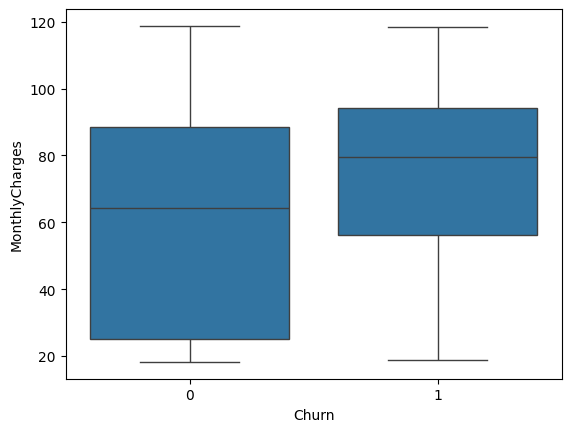

In [15]:
# Churn vs Monthly Charges
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

<Axes: xlabel='Churn', ylabel='TotalCharges'>

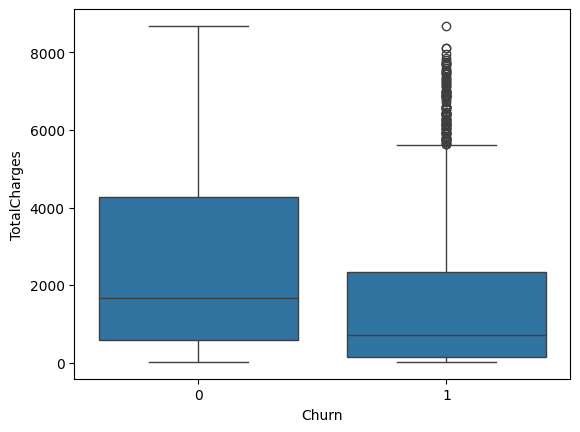

In [16]:
# churn vs Total charges
sns.boxplot(x='Churn', y='TotalCharges', data=df)

## Feature Engineering

In [17]:
# Drop the customerID column
df = df.drop(columns=['customerID'])


The values in tenure have a range of 0 to 72. Binning or Bucketing the tenure values into discrete intervals of 12.

In [18]:
# Binning 'tenure'
df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,36,48,60,72],
                            labels=['0-12','13-24','25-36','37-48','49-60','61-72'],
                           include_lowest=True, right=True)

In [19]:
# Encoding binary features
binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling']

for col in binary_cols:
    df[col]=df[col].map({'Yes':1, 'No':0})
    print('Encoded',col)


Encoded Partner
Encoded Dependents
Encoded PhoneService
Encoded PaperlessBilling


In [20]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
tenure_group        0
dtype: int64

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            7043 non-null   object  
 1   SeniorCitizen     7043 non-null   int64   
 2   Partner           7043 non-null   int64   
 3   Dependents        7043 non-null   int64   
 4   tenure            7043 non-null   int64   
 5   PhoneService      7043 non-null   int64   
 6   MultipleLines     7043 non-null   object  
 7   InternetService   7043 non-null   object  
 8   OnlineSecurity    7043 non-null   object  
 9   OnlineBackup      7043 non-null   object  
 10  DeviceProtection  7043 non-null   object  
 11  TechSupport       7043 non-null   object  
 12  StreamingTV       7043 non-null   object  
 13  StreamingMovies   7043 non-null   object  
 14  Contract          7043 non-null   object  
 15  PaperlessBilling  7043 non-null   int64   
 16  PaymentMethod     7043 n

In [22]:
# Use One hot encoding for other categoricals
df = pd.get_dummies(df, drop_first=True)

In [23]:
df.isnull().sum()

SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
gender_Male                              0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV_No internet service          0
StreamingTV

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 36 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   Partner                                7043 non-null   int64  
 2   Dependents                             7043 non-null   int64  
 3   tenure                                 7043 non-null   int64  
 4   PhoneService                           7043 non-null   int64  
 5   PaperlessBilling                       7043 non-null   int64  
 6   MonthlyCharges                         7043 non-null   float64
 7   TotalCharges                           7043 non-null   float64
 8   Churn                                  7043 non-null   int64  
 9   gender_Male                            7043 non-null   bool   
 10  MultipleLines_No phone service         7043 non-null   bool   
 11  Mult

## Train/Test Split and Scaling

In [25]:
from sklearn.model_selection import train_test_split

x = df.drop('Churn', axis=1)
y = df['Churn']

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, stratify=y, random_state=42)

## Voting Ensemble Pipeline

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# Define base models
estimators = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('dt', DecisionTreeClassifier()),
    ('rf', RandomForestClassifier()),
    ('xgb',XGBClassifier(random_state=42)),
    ('lgbm',LGBMClassifier(class_weight='balanced',random_state=42))
]

# Create ensemble
ensemble = VotingClassifier(estimators=estimators, voting='soft')

# Wrap in pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ensemble', ensemble)
])


In [27]:
## Corss Validation
from sklearn.metrics import roc_auc_score, accuracy_score,f1_score
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(pipe, x_train, y_train, cv=5, scoring="roc_auc")
print("CV Accuracy:", cv_scores.mean())

[LightGBM] [Info] Number of positive: 1196, number of negative: 3311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000714 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 680
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


D:\Newfolder\envs\RP_Env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1196, number of negative: 3311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000405 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 680
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


D:\Newfolder\envs\RP_Env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1196, number of negative: 3311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000358 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 680
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


D:\Newfolder\envs\RP_Env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1196, number of negative: 3311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000360 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 680
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


D:\Newfolder\envs\RP_Env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1196, number of negative: 3312
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000338 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 680
[LightGBM] [Info] Number of data points in the train set: 4508, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
CV Accuracy: 0.8284986458374911


D:\Newfolder\envs\RP_Env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [28]:
# Train final model
pipe.fit(x_train, y_train)

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000477 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 680
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


Pipeline(steps=[('scaler', StandardScaler()),
                ('ensemble',
                 VotingClassifier(estimators=[('lr',
                                               LogisticRegression(max_iter=1000)),
                                              ('dt', DecisionTreeClassifier()),
                                              ('rf', RandomForestClassifier()),
                                              ('xgb',
                                               XGBClassifier(base_score=None,
                                                             booster=None,
                                                             callbacks=None,
                                                             colsample_bylevel=None,
                                                             colsample_bynode=None,
                                                             colsample_bytree=None,
                                                             device=None,
                                                             early_stopping_r...
                                                             learning_rate=None,
                                                             max_bin=None,
                                                             max_cat_threshold=None,
                                                             max_cat_to_onehot=None,
                                                             max_delta_step=None,
                                                             max_depth=None,
                                                             max_leaves=None,
                                                             min_child_weight=None,
                                                             missing=nan,
                                                             monotone_constraints=None,
                                                             multi_strategy=None,
                                                             n_estimators=None,
                                                             n_jobs=None,
                                                             num_parallel_tree=None, ...)),
                                              ('lgbm',
                                               LGBMClassifier(class_weight='balanced',
                                                              random_state=42))],
                                  voting='soft'))])


LR Metrics
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409

ROC-AUC: 0.8429254178614792


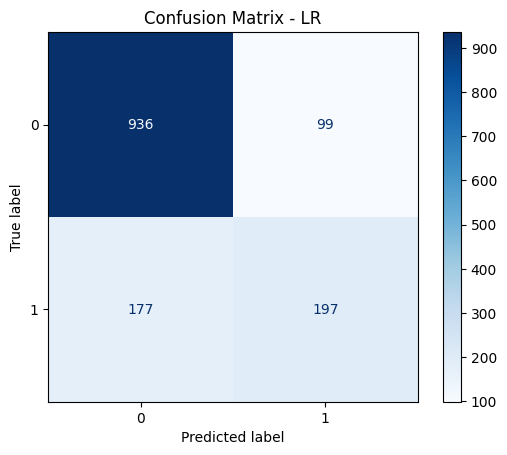


DT Metrics
              precision    recall  f1-score   support

           0       0.81      0.83      0.82      1035
           1       0.50      0.48      0.49       374

    accuracy                           0.73      1409
   macro avg       0.66      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409

ROC-AUC: 0.6505050505050506


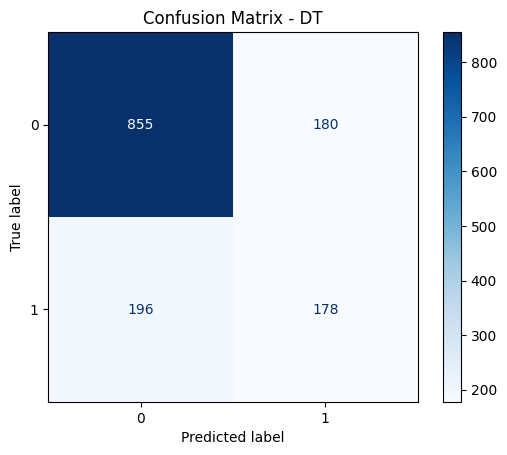


RF Metrics
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409

ROC-AUC: 0.8218889663902452


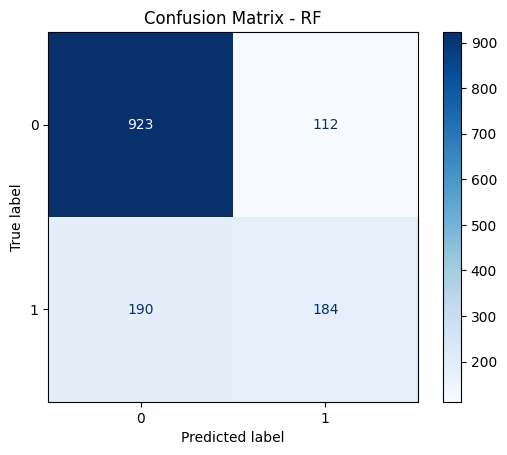


XGB Metrics
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1035
           1       0.61      0.52      0.56       374

    accuracy                           0.78      1409
   macro avg       0.72      0.70      0.71      1409
weighted avg       0.77      0.78      0.78      1409

ROC-AUC: 0.8210558268103023


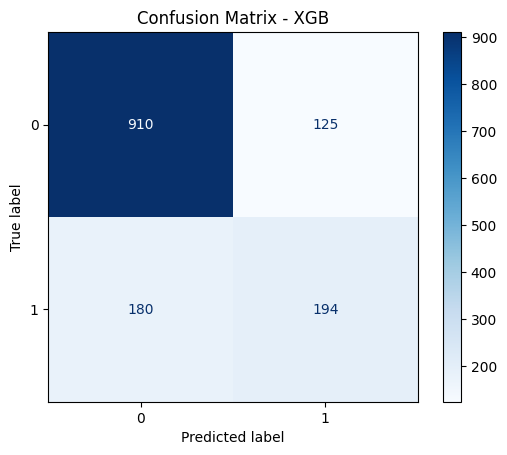


LGBM Metrics
              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1035
           1       0.53      0.76      0.63       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409

ROC-AUC: 0.8348058591025342


D:\Newfolder\envs\RP_Env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\Newfolder\envs\RP_Env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


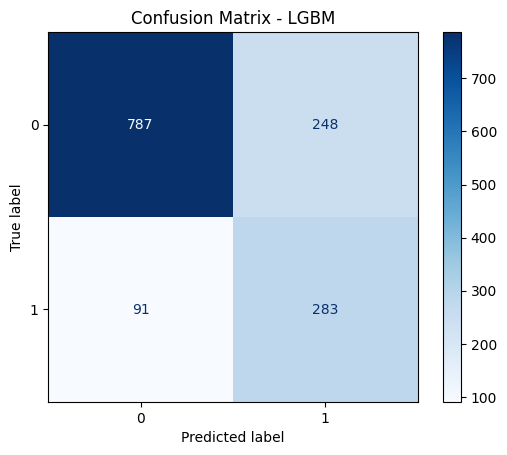

In [29]:
# Model metrics for Dashboard

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def model_metrics(pipeline, x_test, y_test):
    ensemble = pipeline.named_steps['ensemble']
    x_input = pipeline.named_steps['scaler'].transform(x_test)
    
    for name, model in zip(ensemble.estimators, ensemble.estimators_):
        y_pred = model.predict(x_input)
        y_proba = model.predict_proba(x_input)[:, 1] if hasattr(model, "predict_proba") else None

        print(f"\n{name[0].upper()} Metrics")
        print(classification_report(y_test, y_pred, zero_division=0))
        
        if y_proba is not None:
            print("ROC-AUC:", roc_auc_score(y_test, y_proba))

        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap='Blues')
        plt.title(f"Confusion Matrix - {name[0].upper()}")
        plt.show()

model_metrics(pipe, x_test, y_test)

- LightGBM performed the best as it predicted 283 '1' labels correctly, highest among all. 
- Across all the models, the recall for class 1 is quite low, suggesting that the model struggles to identify churners
- ROC-AUC values are decent in 0.8 range, but precison and recall needs imporvement.

## Threshold Tuning

D:\Newfolder\envs\RP_Env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


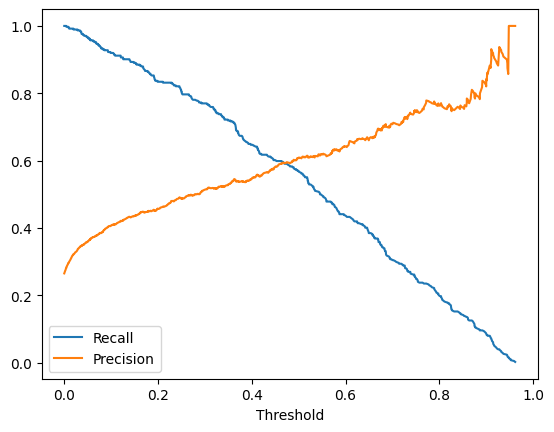

In [30]:
from sklearn.metrics import precision_recall_curve

y_proba = pipe.predict_proba(x_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Plot to find optimal trade-off
plt.plot(thresholds, recall[:-1], label='Recall')
plt.plot(thresholds, precision[:-1], label='Precision')
plt.xlabel('Threshold')
plt.legend()
plt.show()

Based on the threshold tuning graph, a threshold value of 0.35 looks good for improving recall without sacrificing too much precison. I have chosen this value because, at approximately 0.35 threshold value, the recall curve(blue) spikes up a little while the precision remains at about 0.5 , which is acceptable in churn scenarios as false positives are considered less costly than false negatives.

              precision    recall  f1-score   support

           0       0.88      0.77      0.82      1035
           1       0.53      0.72      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409



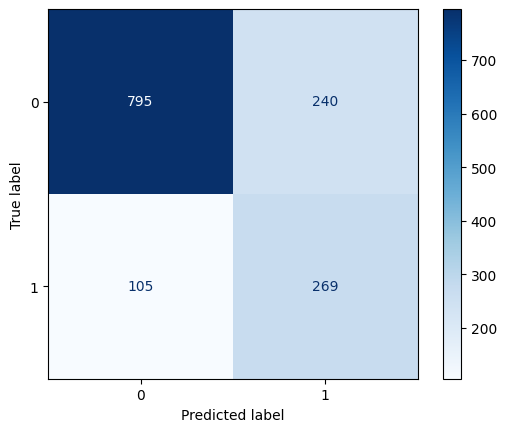

In [31]:
# Applying threshold limit >=0.35
y_pred_custom = (y_proba >= 0.35).astype(int)

# Evaluate new predictions
print(classification_report(y_test, y_pred_custom))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_custom, cmap='Blues')

## Comparision (Default threshold vs. Tuned threshold)

D:\Newfolder\envs\RP_Env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


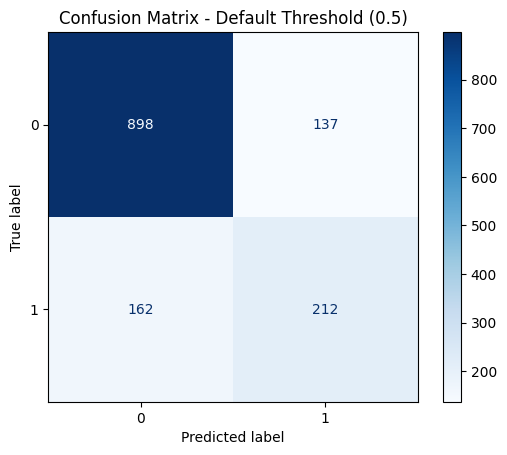

D:\Newfolder\envs\RP_Env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


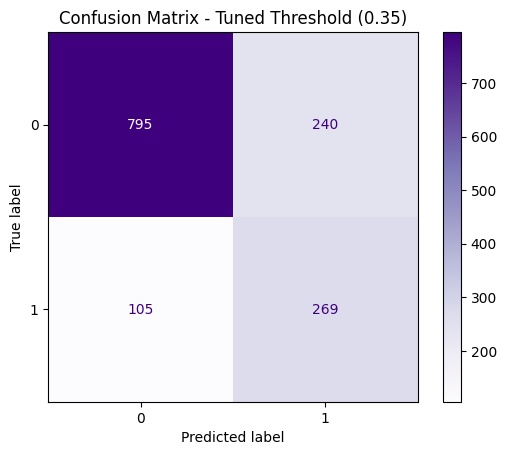

In [32]:
# Default threshold
y_pred_default = pipe.predict(x_test)
cm_default = confusion_matrix(y_test, y_pred_default)
ConfusionMatrixDisplay(cm_default).plot(cmap='Blues')
plt.title("Confusion Matrix - Default Threshold (0.5)")
plt.show()

# Tuned threshold
y_proba = pipe.predict_proba(x_test)[:, 1]
y_pred_tuned = (y_proba >= 0.35).astype(int)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
ConfusionMatrixDisplay(cm_tuned).plot(cmap='Purples')
plt.title("Confusion Matrix - Tuned Threshold (0.35)")
plt.show()

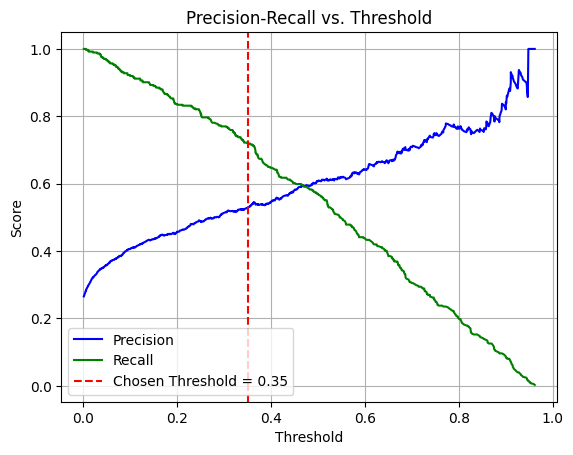

In [33]:
# Threshold tuning curve with marker
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.plot(thresholds, precision[:-1], label='Precision', color='blue')
plt.plot(thresholds, recall[:-1], label='Recall', color='green')
plt.axvline(x=0.35, color='red', linestyle='--', label='Chosen Threshold = 0.35')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs. Threshold')
plt.legend()
plt.grid(True)
plt.show()


## SHAP summary for LightGBM

D:\Newfolder\envs\RP_Env\Lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


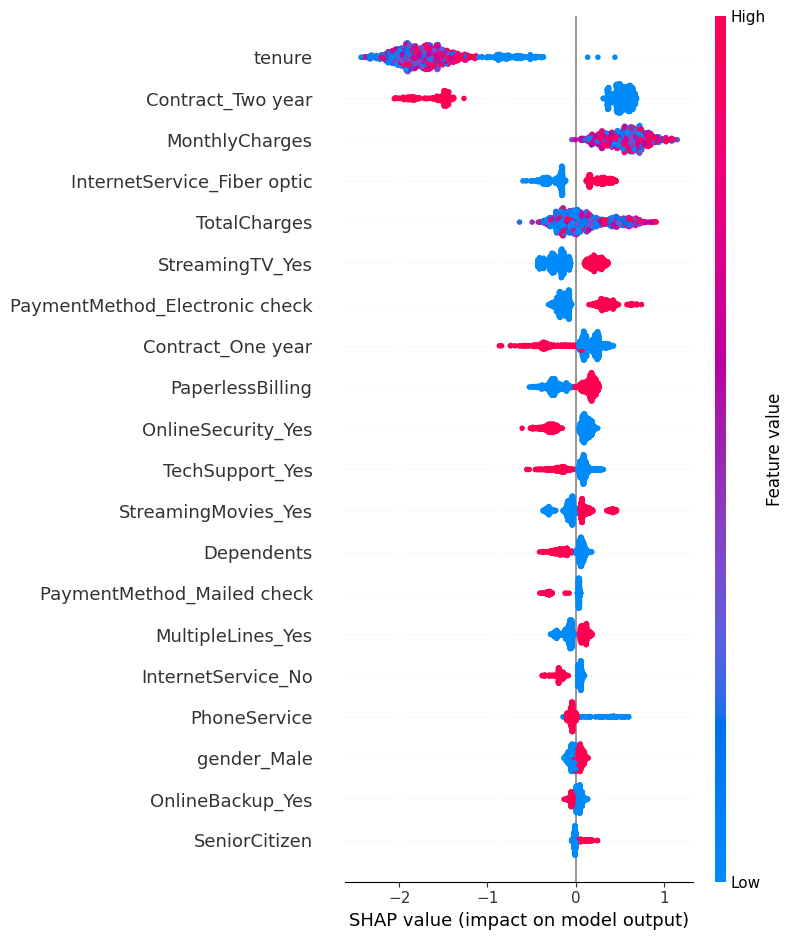

In [34]:
import shap

# Extract LightGBM model from pipeline
lgbm_model = pipe.named_steps['ensemble'].named_estimators_['lgbm']
#x_input = pipe.named_steps['scaler'].transform(x_test)

explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(x_test)

# Summary plot
shap.summary_plot(shap_values, x_test, feature_names=x_test.columns)

### Interpretation:
The SHAP summary plot reveals the most influential features driving churn predictions in the LightGBM model. Each feature’s impact is visualized by how much it pushes the model’s output toward predicting churn (positive SHAP value) or retention (negative SHAP value), with color indicating the feature value (blue-low, red-high). SHAP summary confirms that LightGBM is learning meaningful, interpretable patterns aligned with business intuition.The most influential features are: 
- **Contract**: For both, One-year and Two-year contract, low contracts pushed towards churn preduction. This means that short term contracts(less than 1 or 2 years) strongly increase churn risk while long-term contracts reduce it.
- **Tenure**: The three dots on the right side of y-axis indicate that low tenure customers like new customers, push towards churn prediciton. Long-tenure customers are more likely to stay.
- **MonthlyCharges**: There are more red dots than blue on the right side of y-axis. This implies that high Monthly charges correlate with higher churn risk.
- **TechSupport**: More blue dots on the right side of y-axis, indicate that lack of tech support contributes to churn. Red dots indicate that having tech support reduces churn risk.
- **OnlineSecurity**: More blue dots on the right side of y-axis, indicate that abscense of security services nudges churn risk higher.
- **PaperlessBilling**: Customers with paperless billing show slightly higher churn risk, possibly correlated with short-term contracts.


### Retention Strategy
Focus on new, high-paying customers without support services,they have a higher risk of churn.

## ROC and Precision recall curve for lightGBM

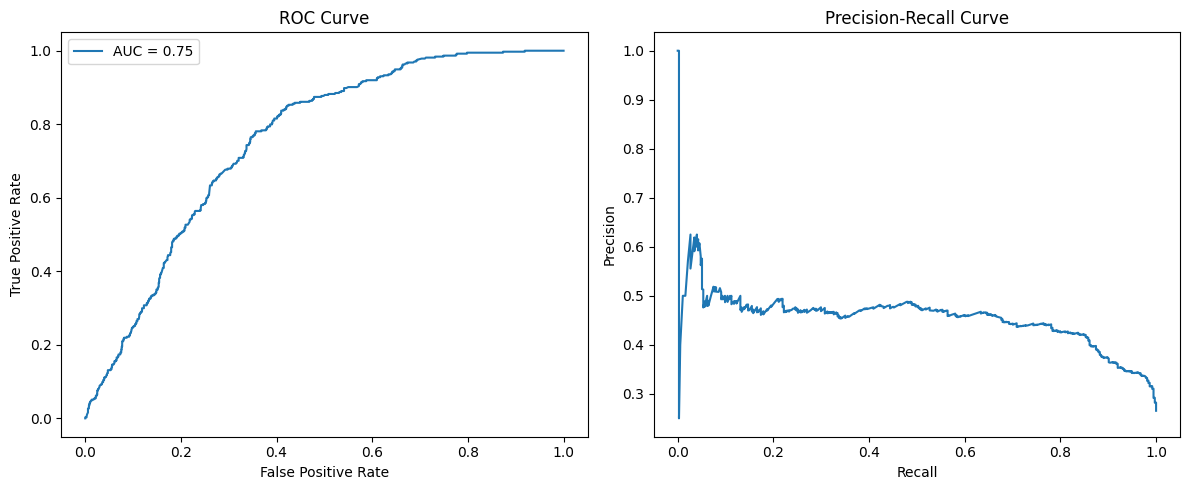

In [36]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt

y_proba = lgbm_model.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.2f}')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(recall, precision)
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.tight_layout()
plt.show()


In [37]:
# prediction on new data 
model = joblib.load('churn_model.pkl')
prediction = model.predict(x_test)

In [41]:
print(classification_report(y_test, prediction))
print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(x_test)[:,1]))

              precision    recall  f1-score   support

           0       0.75      0.94      0.84      1035
           1       0.48      0.15      0.22       374

    accuracy                           0.73      1409
   macro avg       0.62      0.54      0.53      1409
weighted avg       0.68      0.73      0.67      1409

ROC-AUC: 0.7533545170373815
